# Predictive Maintenance Data Preparation


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 60)

DATA_DIR = Path(".")

In [2]:
telemetry = pd.read_csv(DATA_DIR / "PdM_telemetry.csv", parse_dates=["datetime"])
errors = pd.read_csv(DATA_DIR / "PdM_errors.csv", parse_dates=["datetime"])
failures = pd.read_csv(DATA_DIR / "PdM_failures.csv", parse_dates=["datetime"])
machines = pd.read_csv(DATA_DIR / "PdM_machines.csv")
maintenance = pd.read_csv(DATA_DIR / "PdM_maint.csv", parse_dates=["datetime"])

print("Files loaded successfully.")

Files loaded successfully.


In [3]:
tables = {
    "telemetry": telemetry,
    "errors": errors,
    "failures": failures,
    "machines": machines,
    "maintenance": maintenance,
}

for table_name, table in tables.items():
    print(table_name, table.shape)

telemetry (876100, 6)
errors (3919, 3)
failures (761, 3)
machines (100, 3)
maintenance (3286, 3)


In [4]:
telemetry.head()

,datetime,machineID,volt,rotate,pressure,vibration
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511


In [5]:
errors.head()

,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


In [6]:
failures.head()

,datetime,machineID,failure
0,2015-01-05 06:00:00,1,comp4
1,2015-03-06 06:00:00,1,comp1
2,2015-04-20 06:00:00,1,comp2
3,2015-06-19 06:00:00,1,comp4
4,2015-09-02 06:00:00,1,comp4


In [7]:
machines.head()

,machineID,model,age
0,1,model3,18
1,2,model4,7
2,3,model3,8
3,4,model3,7
4,5,model3,2


In [8]:
maintenance.head()

,datetime,machineID,comp
0,2014-06-01 06:00:00,1,comp2
1,2014-07-16 06:00:00,1,comp4
2,2014-07-31 06:00:00,1,comp3
3,2014-12-13 06:00:00,1,comp1
4,2015-01-05 06:00:00,1,comp4


## . Check Missing Values


In [9]:
for table_name, table in tables.items():
    print("\n" + table_name.upper())
    print(table.isna().sum())


TELEMETRY
datetime     0
machineID    0
volt         0
rotate       0
pressure     0
vibration    0
dtype: int64

ERRORS
datetime     0
machineID    0
errorID      0
dtype: int64

FAILURES
datetime     0
machineID    0
failure      0
dtype: int64

MACHINES
machineID    0
model        0
age          0
dtype: int64

MAINTENANCE
datetime     0
machineID    0
comp         0
dtype: int64


##  Check Duplicate Rows


In [10]:
for table_name, table in tables.items():
    print(table_name, "duplicate rows:", table.duplicated().sum())

telemetry duplicate rows: 0
errors duplicate rows: 0
failures duplicate rows: 0
machines duplicate rows: 0
maintenance duplicate rows: 0


##  Simple Data Cleaning


In [11]:
telemetry = telemetry.drop_duplicates().sort_values(["machineID", "datetime"]).reset_index(drop=True)
errors = errors.drop_duplicates().sort_values(["machineID", "datetime"]).reset_index(drop=True)
failures = failures.drop_duplicates().sort_values(["machineID", "datetime"]).reset_index(drop=True)
machines = machines.drop_duplicates().sort_values("machineID").reset_index(drop=True)
maintenance = maintenance.drop_duplicates().sort_values(["machineID", "datetime"]).reset_index(drop=True)

print("Cleaning completed.")

Cleaning completed.


##  Explore Sensor Columns


In [12]:
sensor_columns = ["volt", "rotate", "pressure", "vibration"]

telemetry[sensor_columns].describe()

,volt,rotate,pressure,vibration
count,876100.000000,876100.000000,876100.000000,876100.000000
mean,170.777736,446.605119,100.858668,40.385007
std,15.509114,52.673886,11.048679,5.370361
min,97.333604,138.432075,51.237106,14.877054
25%,160.304927,412.305714,93.498181,36.777299
50%,170.607338,447.558150,100.425559,40.237247
75%,181.004493,482.176600,107.555231,43.784938
max,255.124717,695.020984,185.951998,76.791072


##  Plot Sensor Distributions


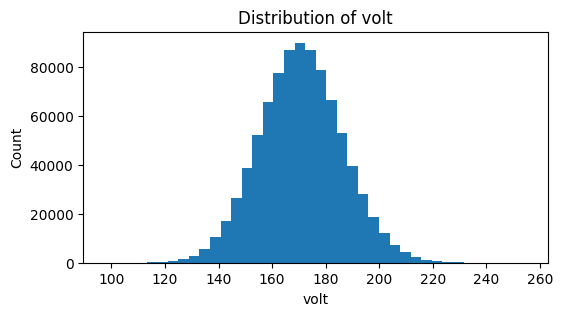

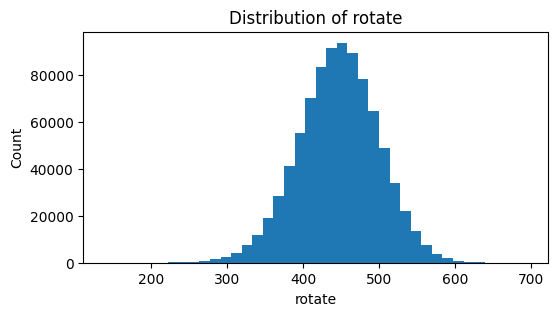

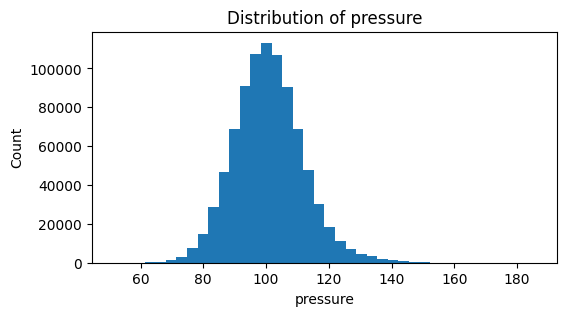

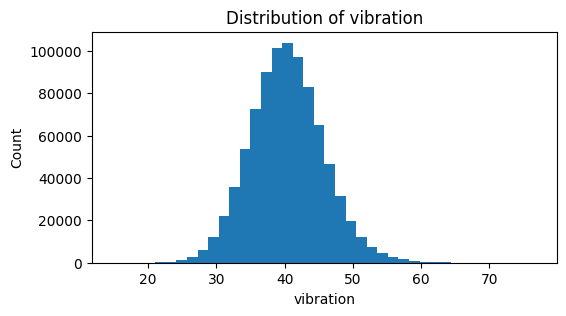

In [13]:
for column in sensor_columns:
    plt.figure(figsize=(6, 3))
    plt.hist(telemetry[column], bins=40)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.show()

##  Explore Machines


In [14]:
machines["model"].value_counts()

model
model3    35
model4    32
model2    17
model1    16
Name: count, dtype: int64

In [15]:
machines["age"].describe()

count    100.000000
mean      11.330000
std        5.856974
min        0.000000
25%        6.750000
50%       12.000000
75%       16.000000
max       20.000000
Name: age, dtype: float64

##  Explore Error, Failure, and Maintenance Counts


In [16]:
print("Error counts:")
print(errors["errorID"].value_counts())

print("\nFailure counts:")
print(failures["failure"].value_counts())

print("\nMaintenance counts:")
print(maintenance["comp"].value_counts())

Error counts:
errorID
error1    1010
error2     988
error3     838
error4     727
error5     356
Name: count, dtype: int64

Failure counts:
failure
comp2    259
comp1    192
comp4    179
comp3    131
Name: count, dtype: int64

Maintenance counts:
comp
comp2    863
comp4    811
comp3    808
comp1    804
Name: count, dtype: int64


##  Create the Main Data Table


In [17]:
data = telemetry.merge(machines, on="machineID", how="left")

data.head()

,datetime,machineID,volt,rotate,pressure,vibration,model,age
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,model3,18
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,model3,18
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,model3,18
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,model3,18
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,model3,18


##  Add Time Features


In [18]:
data["hour"] = data["datetime"].dt.hour
data["dayofweek"] = data["datetime"].dt.dayofweek
data["month"] = data["datetime"].dt.month

data[["datetime", "hour", "dayofweek", "month"]].head()

,datetime,hour,dayofweek,month
0,2015-01-01 06:00:00,6,3,1
1,2015-01-01 07:00:00,7,3,1
2,2015-01-01 08:00:00,8,3,1
3,2015-01-01 09:00:00,9,3,1
4,2015-01-01 10:00:00,10,3,1


##  Add Rolling Sensor Averages


In [19]:
for column in sensor_columns:
    data[f"{column}_mean_3h"] = (
        data.groupby("machineID")[column]
        .rolling(window=3, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

    data[f"{column}_mean_24h"] = (
        data.groupby("machineID")[column]
        .rolling(window=24, min_periods=1)
        .mean()
        .reset_index(level=0, drop=True)
    )

data.head()

,datetime,machineID,volt,rotate,pressure,vibration,model,age,hour,dayofweek,month,volt_mean_3h,volt_mean_24h,rotate_mean_3h,rotate_mean_24h,pressure_mean_3h,pressure_mean_24h,vibration_mean_3h,vibration_mean_24h
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,model3,18,6,3,1,176.217853,176.217853,418.504078,418.504078,113.077935,113.077935,45.087686,45.087686
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,model3,18,7,3,1,169.548538,169.548538,410.625784,410.625784,104.269230,104.269230,44.250829,44.250829
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,model3,18,8,3,1,170.028993,170.028993,449.533798,449.533798,94.592122,94.592122,40.893502,40.893502
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,model3,18,9,3,1,165.443986,168.137453,425.415550,423.687682,93.315664,98.256232,39.571655,40.950662
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,model3,18,10,3,1,163.687586,166.031967,436.292011,426.025520,98.791038,100.982315,33.763834,37.958632


## Add Error Count Feature


In [20]:
error_counts = (
    errors.assign(error_now=1)
    .groupby(["machineID", "datetime"], as_index=False)["error_now"]
    .sum()
)

data = data.merge(error_counts, on=["machineID", "datetime"], how="left")
data["error_now"] = data["error_now"].fillna(0).astype(int)

data["error_count_24h"] = (
    data.groupby("machineID")["error_now"]
    .rolling(window=24, min_periods=1)
    .sum()
    .reset_index(level=0, drop=True)
    .astype(int)
)

data[["machineID", "datetime", "error_now", "error_count_24h"]].head()

,machineID,datetime,error_now,error_count_24h
0,1,2015-01-01 06:00:00,0,0
1,1,2015-01-01 07:00:00,0,0
2,1,2015-01-01 08:00:00,0,0
3,1,2015-01-01 09:00:00,0,0
4,1,2015-01-01 10:00:00,0,0


## Add Simple Error Type Columns


In [21]:
error_types = pd.get_dummies(errors["errorID"], prefix="error", dtype=int)
error_type_data = pd.concat([errors[["machineID", "datetime"]], error_types], axis=1)

error_type_data = error_type_data.groupby(["machineID", "datetime"], as_index=False).sum()

data = data.merge(error_type_data, on=["machineID", "datetime"], how="left")

error_type_columns = [col for col in data.columns if col.startswith("error_error")]
data[error_type_columns] = data[error_type_columns].fillna(0).astype(int)

data[["machineID", "datetime"] + error_type_columns].head()

,machineID,datetime,error_error1,error_error2,error_error3,error_error4,error_error5
0,1,2015-01-01 06:00:00,0,0,0,0,0
1,1,2015-01-01 07:00:00,0,0,0,0,0
2,1,2015-01-01 08:00:00,0,0,0,0,0
3,1,2015-01-01 09:00:00,0,0,0,0,0
4,1,2015-01-01 10:00:00,0,0,0,0,0


## Add Maintenance Features


In [22]:
maintenance_dates = maintenance[["machineID", "datetime"]].drop_duplicates()
maintenance_dates["maintenance_happened"] = 1

data = data.merge(maintenance_dates, on=["machineID", "datetime"], how="left")
data["maintenance_happened"] = data["maintenance_happened"].fillna(0).astype(int)

data["last_maint_datetime"] = data["datetime"].where(data["maintenance_happened"] == 1)
data["last_maint_datetime"] = data.groupby("machineID")["last_maint_datetime"].ffill()

data["days_since_maint"] = (data["datetime"] - data["last_maint_datetime"]).dt.total_seconds() / (24 * 60 * 60)
data["days_since_maint"] = data["days_since_maint"].fillna(0)

data["maint_overdue_30d"] = (data["days_since_maint"] > 30).astype(int)

data[["machineID", "datetime", "maintenance_happened", "last_maint_datetime", "days_since_maint", "maint_overdue_30d"]].head()

,machineID,datetime,maintenance_happened,last_maint_datetime,days_since_maint,maint_overdue_30d
0,1,2015-01-01 06:00:00,0,NaT,0.0,0
1,1,2015-01-01 07:00:00,0,NaT,0.0,0
2,1,2015-01-01 08:00:00,0,NaT,0.0,0
3,1,2015-01-01 09:00:00,0,NaT,0.0,0
4,1,2015-01-01 10:00:00,0,NaT,0.0,0


## Create the Target: Failure in Next 24 Hours


In [23]:
danger_times = []

for index, failure in failures.iterrows():
    machine_id = failure["machineID"]
    failure_time = failure["datetime"]
    component = failure["failure"]

    for hour in range(25):
        danger_time = failure_time - pd.Timedelta(hours=hour)
        danger_times.append([machine_id, danger_time, 1, component])

danger_times = pd.DataFrame(
    danger_times,
    columns=["machineID", "datetime", "failure_next_24h", "failure_component"]
)

danger_times = danger_times.drop_duplicates(["machineID", "datetime"])

data = data.merge(danger_times, on=["machineID", "datetime"], how="left")
data["failure_next_24h"] = data["failure_next_24h"].fillna(0).astype(int)
data["failure_component"] = data["failure_component"].fillna("none")

data[["machineID", "datetime", "failure_next_24h", "failure_component"]].head()

,machineID,datetime,failure_next_24h,failure_component
0,1,2015-01-01 06:00:00,0,none
1,1,2015-01-01 07:00:00,0,none
2,1,2015-01-01 08:00:00,0,none
3,1,2015-01-01 09:00:00,0,none
4,1,2015-01-01 10:00:00,0,none


## Check Target Balance


In [24]:
target_balance = data["failure_next_24h"].value_counts().reset_index()
target_balance.columns = ["failure_next_24h", "rows"]
target_balance["percentage"] = (target_balance["rows"] / len(data) * 100).round(3)

target_balance

,failure_next_24h,rows,percentage
0,0,858198,97.957
1,1,17902,2.043


## Convert Machine Model into Number Columns


In [25]:
data = pd.get_dummies(data, columns=["model"], prefix="model", dtype=int)

data.head()

,datetime,machineID,volt,rotate,pressure,vibration,age,hour,dayofweek,month,volt_mean_3h,volt_mean_24h,rotate_mean_3h,rotate_mean_24h,pressure_mean_3h,pressure_mean_24h,vibration_mean_3h,vibration_mean_24h,error_now,error_count_24h,error_error1,error_error2,error_error3,error_error4,error_error5,maintenance_happened,last_maint_datetime,days_since_maint,maint_overdue_30d,failure_next_24h,failure_component,model_model1,model_model2,model_model3,model_model4
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,18,6,3,1,176.217853,176.217853,418.504078,418.504078,113.077935,113.077935,45.087686,45.087686,0,0,0,0,0,0,0,0,NaT,0.0,0,0,none,0,0,1,0
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,18,7,3,1,169.548538,169.548538,410.625784,410.625784,104.269230,104.269230,44.250829,44.250829,0,0,0,0,0,0,0,0,NaT,0.0,0,0,none,0,0,1,0
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,18,8,3,1,170.028993,170.028993,449.533798,449.533798,94.592122,94.592122,40.893502,40.893502,0,0,0,0,0,0,0,0,NaT,0.0,0,0,none,0,0,1,0
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,18,9,3,1,165.443986,168.137453,425.415550,423.687682,93.315664,98.256232,39.571655,40.950662,0,0,0,0,0,0,0,0,NaT,0.0,0,0,none,0,0,1,0
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,18,10,3,1,163.687586,166.031967,436.292011,426.025520,98.791038,100.982315,33.763834,37.958632,0,0,0,0,0,0,0,0,NaT,0.0,0,0,none,0,0,1,0


## Choose Final Columns


In [26]:
columns_to_remove = [
    "last_maint_datetime",
    "failure_component",
]

modeling_data = data.drop(columns=columns_to_remove)

print("Final dataset shape:", modeling_data.shape)
modeling_data.head()

Final dataset shape: (876100, 33)


,datetime,machineID,volt,rotate,pressure,vibration,age,hour,dayofweek,month,volt_mean_3h,volt_mean_24h,rotate_mean_3h,rotate_mean_24h,pressure_mean_3h,pressure_mean_24h,vibration_mean_3h,vibration_mean_24h,error_now,error_count_24h,error_error1,error_error2,error_error3,error_error4,error_error5,maintenance_happened,days_since_maint,maint_overdue_30d,failure_next_24h,model_model1,model_model2,model_model3,model_model4
0,2015-01-01 06:00:00,1,176.217853,418.504078,113.077935,45.087686,18,6,3,1,176.217853,176.217853,418.504078,418.504078,113.077935,113.077935,45.087686,45.087686,0,0,0,0,0,0,0,0,0.0,0,0,0,0,1,0
1,2015-01-01 07:00:00,1,162.879223,402.747490,95.460525,43.413973,18,7,3,1,169.548538,169.548538,410.625784,410.625784,104.269230,104.269230,44.250829,44.250829,0,0,0,0,0,0,0,0,0.0,0,0,0,0,1,0
2,2015-01-01 08:00:00,1,170.989902,527.349825,75.237905,34.178847,18,8,3,1,170.028993,170.028993,449.533798,449.533798,94.592122,94.592122,40.893502,40.893502,0,0,0,0,0,0,0,0,0.0,0,0,0,0,1,0
3,2015-01-01 09:00:00,1,162.462833,346.149335,109.248561,41.122144,18,9,3,1,165.443986,168.137453,425.415550,423.687682,93.315664,98.256232,39.571655,40.950662,0,0,0,0,0,0,0,0,0.0,0,0,0,0,1,0
4,2015-01-01 10:00:00,1,157.610021,435.376873,111.886648,25.990511,18,10,3,1,163.687586,166.031967,436.292011,426.025520,98.791038,100.982315,33.763834,37.958632,0,0,0,0,0,0,0,0,0.0,0,0,0,0,1,0


## Final Feature List


In [27]:
target_column = "failure_next_24h"

feature_columns = [col for col in modeling_data.columns if col != target_column]

print("Target column:", target_column)
print("Number of feature columns:", len(feature_columns))

feature_columns

Target column: failure_next_24h
Number of feature columns: 32


['datetime',
 'machineID',
 'volt',
 'rotate',
 'pressure',
 'vibration',
 'age',
 'hour',
 'dayofweek',
 'month',
 'volt_mean_3h',
 'volt_mean_24h',
 'rotate_mean_3h',
 'rotate_mean_24h',
 'pressure_mean_3h',
 'pressure_mean_24h',
 'vibration_mean_3h',
 'vibration_mean_24h',
 'error_now',
 'error_count_24h',
 'error_error1',
 'error_error2',
 'error_error3',
 'error_error4',
 'error_error5',
 'maintenance_happened',
 'days_since_maint',
 'maint_overdue_30d',
 'model_model1',
 'model_model2',
 'model_model3',
 'model_model4']

##  Save the Prepared Dataset


In [28]:
modeling_data.to_csv(DATA_DIR / "pdm_modeling_data.csv", index=False)
pd.Series(feature_columns, name="feature").to_csv(DATA_DIR / "pdm_feature_columns.csv", index=False)

print("Saved pdm_modeling_data.csv")
print("Saved pdm_feature_columns.csv")


Saved pdm_modeling_data.csv
Saved pdm_feature_columns.csv
